In [1]:
# import sys
# sys.path.append('/home/semik/projekty/ml_attempts/noncanonical_introns_master/')

# import pathlib
# pathlib.Path().absolute()

import introns

In [2]:
genome, genes = introns.HELP_load_default_genome_genes(species="EL")

Creating genes, sequences, introns, exons and introns' class prediction


100%|██████████| 38192/38192 [01:03<00:00, 602.62it/s]

[CREATE] Genes, sequences, introns, exons created, introns' classes predicted


In [3]:
for name,gene in list(genes.items())[:50]:
    for intron in gene.introns:
        if intron.is_conventional or intron.is_nonconventional:
            print(intron.is_conventional, intron.is_nonconventional)
        for v in intron.variants:
            if v.is_conventional or v.is_nonconventional:
                print("\n", v.is_conventional, v.is_nonconventional)

0 2
0 9

 0 9

 0 9

 0 7

 0 2

 0 2
6 8

 6 8
8 0
8 0
8 0
8 0
8 0
8 0
8 0
3 0
3 0
1 0

 1 0
3 0
3 0
4 0
2 0

 2 0
3 0

 3 0
7 0
8 0
2 0

 2 0
3 0

 3 0
0 7

 0 7

 0 9


In [4]:
print("conventional versions of variants")
for name,gene in list(genes.items()):
    for intron in gene.introns:
        if intron.is_conventional or intron.best_conv_var:
            print(intron.is_conventional, intron.best_conv_var, [i.is_conventional for i in intron.variants])
print("nonconventional versions of variants")
for name,gene in list(genes.items()):
    for intron in gene.introns:
        if intron.is_nonconventional or intron.best_nonconv_var:
            print(intron.is_nonconventional, intron.best_nonconv_var, [i.is_nonconventional for i in intron.variants])

conventional versions of variants
6 6 [0, 0, 6]
8 8 []
8 8 []
8 8 []
8 8 []
8 8 []
8 8 []
8 8 []
3 3 [0, 0]
3 3 [0, 0, 0]
1 1 [0, 0, 1, 0]
3 3 [0]
3 3 [0]
4 4 []
2 2 [0, 2]
3 3 [3]
7 7 [0, 0, 0, 0, 0]
8 8 [0]
2 2 [0, 0, 2]
3 3 [3]
1 1 [0, 0, 1, 0, 0]
3 3 [0, 0, 0]
3 3 [0]
3 3 [0, 0]
3 3 [0, 0, 0]
5 5 [0, 0, 5]
2 2 [0, 0, 2]
3 3 [0]
3 3 [0, 0, 0]
3 3 [0]
3 3 [0, 0]
3 3 [0, 0, 0]
5 5 [0, 0, 5]
2 2 [0, 0, 2]
3 3 [0]
6 6 [0, 6]
3 3 [0, 0, 0]
3 3 [0]
3 3 [0, 0]
3 3 [0, 0, 0]
5 5 [0, 0, 5]
2 2 [0, 0, 2]
3 3 [0]
6 6 [0, 6]
4 4 [0, 4]
3 3 [0]
2 2 [0, 0, 0, 2]
5 5 [0, 0, 5]
2 2 [0, 0, 2]
2 2 [0, 2, 0]
4 4 [0, 4]
3 3 [0]
2 2 [0, 0, 0, 2]
5 5 [0, 0, 5]
2 2 [0, 0, 2]
2 2 [0, 2, 0]
2 2 [0, 0, 2]
4 4 [0, 0, 0]
3 3 [0, 0, 0]
2 2 [0, 0, 2]
2 2 [0, 2]
2 2 [0, 0, 2]
3 3 [3, 0]
3 3 [0, 0]
4 4 [0, 4, 0, 0, 0]
3 3 [0, 0]
2 2 [0, 2]
1 1 [0, 0, 1, 0]
1 1 [0, 0, 0, 1, 0]
2 2 [0, 0, 2]
2 2 [0, 0, 0, 2]
8 8 [0, 0, 0, 0]
2 2 [0, 2]
7 7 [0, 0, 0]
3 3 [0, 0]
4 4 [0]
7 7 [0]
8 8 [0, 8]
7 7 [7]
3 3 [3]
2 2 [0, 2]
8 

In [5]:
import matplotlib.pyplot as plt
print("no. of introns' variants")
no_of_variants = [len(intron.variants) for _, gene in list(genes.items()) for intron in gene.introns]

no. of introns' variants


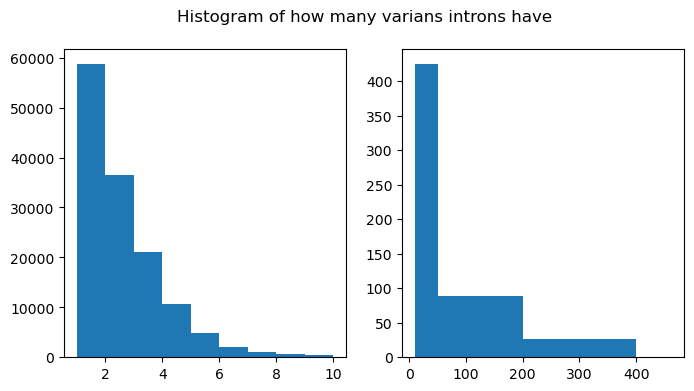

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(8,4))
ax[0].hist(no_of_variants, bins=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]);
ax[1].hist(no_of_variants, bins=[10, 50, 200, 400, max(no_of_variants)]);
fig.suptitle("Histogram of how many varians introns have")
plt.show()

In [7]:
for name, gene in list(genes.items()):
    for intron in gene.introns:
        for var in intron.variants:
            if not var.prev_exon.scaffold_end == var.scaffold_start or not var.scaffold_end==var.next_exon.scaffold_start:
                print('start/end are wrong')

In [8]:
print("eksony maja swoje poprzedzajace i nastepne eksony")
for name, gene in list(genes.items()):
    if len(gene.exons)<2:
        continue
    for exon in gene.exons:
        if not exon.prev_exon and not exon.next_exon:
            print(f"Exon in gene {name} does not have any neighbouring exons???")

eksony maja swoje poprzedzajace i nastepne eksony


In [9]:
print('introny tez maja poprzedzajace i nastepne eksony')
for name, gene in list(genes.items()):
    gene.extract_sequence(genome)
    gene.create_introns()
    for intron in gene.introns:
        g_prev = intron.prev_exon.scaffold_end == intron.scaffold_start
        g_next = intron.scaffold_end==intron.next_exon.scaffold_start
        if not g_prev and not g_next:
            print(f"Intron in {name} does not have neighbouring exons???")

introny tez maja poprzedzajace i nastepne eksony


In [10]:
print("eksony maja tez poprzedzajace i nastepne introny")
        
for name, gene in list(genes.items()):
    if len(gene.exons)==1:
        #print("only one exon in gene, hence no introns")
        continue
    for exon in gene.exons:
        if not exon.prev_intron and not exon.next_intron:
            raise ValueError(f"Exon in gene {name} does not have both neighbouring introns???")

eksony maja tez poprzedzajace i nastepne introny


In [11]:
genome_EG, genes_EG = introns.HELP_load_default_genome_genes(species="EG")

Creating genes, sequences, introns, exons and introns' class prediction


100%|██████████| 275238/275238 [05:21<00:00, 856.03it/s] 

[CREATE] Genes, sequences, introns, exons created, introns' classes predicted


In [12]:
stale = len([intron for (_, gene) in genes_EG.items()
             for intron in gene.introns
             if len(intron.variants)==0])
print(stale)

372670


In [14]:
name, conventional_classes, nonconventional_classes,\
    conv_count,nconv_count, both_count,\
        non_count,all_count = introns.counting_introns("EG", genome_EG, genes_EG)
print(sum(conventional_classes)==conv_count)
print(sum(nonconventional_classes)==nconv_count)

EG
          Conventional: 92001
          Nonconventional: 73029
          Both: 3606
          Other: 847051
          All: 1015687
True
True
